In [ ]:
"""make variations of input image"""

import argparse, os, sys, glob
import PIL
import torch
import torch.nn as nn
import numpy as np
from omegaconf import OmegaConf
from PIL import Image
from tqdm import tqdm, trange
from itertools import islice
from einops import rearrange, repeat
from torchvision.utils import make_grid
from torch import autocast
from contextlib import nullcontext
import time
from pytorch_lightning import seed_everything

sys.path.append(os.path.dirname(sys.path[0]))
from ldm.util import instantiate_from_config
from ldm.models.diffusion.ddim import DDIMSampler
from ldm.models.diffusion.plms import PLMSSampler

from transformers import CLIPProcessor, CLIPModel

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

def chunk(it, size):
    it = iter(it)
    return iter(lambda: tuple(islice(it, size)), ())


def load_model_from_config(config, ckpt, verbose=False):
    print(f"Loading model from {ckpt}")
    pl_sd = torch.load(ckpt, map_location="cpu")
    if "global_step" in pl_sd:
        print(f"Global Step: {pl_sd['global_step']}")
    sd = pl_sd["state_dict"]
    model = instantiate_from_config(config.model)
    m, u = model.load_state_dict(sd, strict=False)
    if len(m) > 0 and verbose:
        print("missing keys:")
        print(m)
    if len(u) > 0 and verbose:
        print("unexpected keys:")
        print(u)

    model.to(device)
    model.eval()
    return model

#loading
def load_img(path):
    image = Image.open(path).convert("RGB")
    w, h = image.size
    print(f"loaded input image of size ({w}, {h}) from {path}")
    w, h = map(lambda x: x - x % 32, (w, h))  # resize to integer multiple of 32
    image = image.resize((512, 512), resample=PIL.Image.LANCZOS)
    image = np.array(image).astype(np.float32) / 255.0
    image = image[None].transpose(0, 3, 1, 2)
    image = torch.from_numpy(image)
    return 2.*image - 1.

def adain(content_feat, style_feat):
    assert (content_feat.size()[:2] == style_feat.size()[:2])
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)

    normalized_feat = (content_feat - content_mean.expand(
        size)) / content_std.expand(size)
    return normalized_feat * style_std.expand(size) + style_mean.expand(size)
        

def calc_mean_std(feat, eps=1e-5):
    # eps is a small value added to the variance to avoid divide-by-zero.
    size = feat.size()
    assert (len(size) == 4)
    N, C = size[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std       

c:\Users\tsriv\anaconda3\envs\ldm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config="configs/stable-diffusion/v1-inference.yaml"
ckpt="models/sd/sd-v1-4.ckpt"
config = OmegaConf.load(f"{config}")
model = load_model_from_config(config, f"{ckpt}")
sampler = DDIMSampler(model)

Loading model from models/sd/sd-v1-4.ckpt
Global Step: 470000
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.52 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


Some weights of the model checkpoint at openai/clip-vit-large-patch14 were not used when initializing CLIPTextModel: ['vision_model.encoder.layers.9.layer_norm2.bias', 'vision_model.encoder.layers.13.layer_norm2.weight', 'vision_model.encoder.layers.10.self_attn.q_proj.bias', 'vision_model.pre_layrnorm.weight', 'vision_model.encoder.layers.5.self_attn.out_proj.bias', 'vision_model.encoder.layers.23.self_attn.q_proj.weight', 'vision_model.encoder.layers.11.self_attn.q_proj.weight', 'vision_model.encoder.layers.19.self_attn.k_proj.bias', 'vision_model.encoder.layers.18.mlp.fc2.weight', 'vision_model.encoder.layers.1.mlp.fc1.bias', 'vision_model.encoder.layers.1.layer_norm2.weight', 'vision_model.encoder.layers.16.layer_norm2.weight', 'vision_model.encoder.layers.22.self_attn.k_proj.weight', 'vision_model.encoder.layers.23.mlp.fc2.bias', 'vision_model.encoder.layers.12.mlp.fc1.bias', 'vision_model.encoder.layers.14.mlp.fc1.weight', 'vision_model.encoder.layers.2.self_attn.k_proj.bias', 'v

In [3]:
def main(prompt = '', content_dir = '', style_dir='',ddim_steps = 50,strength = 0.5, model = None, seed=42):
    ddim_eta=0.0
    n_iter=1
    C=4
    f=8
    n_samples=1
    n_rows=0
    scale=10.0
    
    precision="autocast"
    outdir="outputs/img2img-samples"
    seed_everything(seed)


    os.makedirs(outdir, exist_ok=True)
    outpath = outdir

    batch_size = n_samples
    n_rows = n_rows if n_rows > 0 else batch_size
    data = [batch_size * [prompt]]


    sample_path = os.path.join(outpath, "samples")
    os.makedirs(sample_path, exist_ok=True)
    base_count = len(os.listdir(sample_path))
    grid_count = len(os.listdir(outpath)) + 10
    
    style_image = load_img(style_dir).to(device)
    style_image = repeat(style_image, '1 ... -> b ...', b=batch_size)
    style_latent = model.get_first_stage_encoding(model.encode_first_stage(style_image))  # move to latent space

    content_name =  content_dir.split('/')[-1].split('.')[0]
    content_image = load_img(content_dir).to(device)
    content_image = repeat(content_image, '1 ... -> b ...', b=batch_size)
    content_latent = model.get_first_stage_encoding(model.encode_first_stage(content_image))  # move to latent space

    # init_latent = adain(content_latent,style_latent) # with AdaIN 
    init_latent = content_latent # without AdaIN 

    sampler.make_schedule(ddim_num_steps=ddim_steps, ddim_eta=ddim_eta, verbose=False)

    assert 0. <= strength <= 1., 'can only work with strength in [0.0, 1.0]'
    t_enc = int(strength * ddim_steps)
    print(f"target t_enc is {t_enc} steps")

    precision_scope = autocast if precision == "autocast" else nullcontext
    with torch.no_grad():
        with precision_scope("cuda"):
            with model.ema_scope():
                tic = time.time()
                all_samples = list()
                for n in trange(n_iter, desc="Sampling"):
                    for prompts in tqdm(data, desc="data"):
                        uc = None
                        if scale != 1.0:
                            uc = model.get_learned_conditioning(batch_size * [""], x=None)
                            # uc = model.get_learned_conditioning(batch_size * [""], style_image)
                        if isinstance(prompts, tuple):
                            prompts = list(prompts)

                        c= model.get_learned_conditioning(prompts, x= None)
                        # c= model.get_learned_conditioning(prompts, style_image)

                        # img2img

                        # stochastic encode
                        # z_enc = sampler.stochastic_encode(init_latent, torch.tensor([t_enc]*batch_size).to(device))

                        # stochastic inversion
                        t_enc = int(strength * 1000) 
                        x_noisy = model.q_sample(x_start=init_latent, t=torch.tensor([t_enc]*batch_size).to(device))
                        model_output = model.apply_model(x_noisy, torch.tensor([t_enc]*batch_size).to(device), c)
                        z_enc = sampler.stochastic_encode(init_latent, torch.tensor([t_enc]*batch_size).to(device),\
                                                          noise = model_output, use_original_steps = True)
            
                        t_enc = int(strength * ddim_steps)
                        samples = sampler.decode(z_enc, c, t_enc, 
                                                unconditional_guidance_scale=scale,
                                                 unconditional_conditioning=uc,)
                        print(z_enc.shape, uc.shape, t_enc)

                        # txt2img
            #             noise  =torch.randn_like(content_latent)
            #             samples, intermediates =sampler.sample(ddim_steps,1,(4,512,512),c,verbose=False, eta=1.,x_T = noise,
            #    unconditional_guidance_scale=scale,
            #    unconditional_conditioning=uc,)

                        x_samples = model.decode_first_stage(samples)

                        x_samples = torch.clamp((x_samples + 1.0) / 2.0, min=0.0, max=1.0)

                        for x_sample in x_samples:
                            x_sample = 255. * rearrange(x_sample.cpu().numpy(), 'c h w -> h w c')
                            base_count += 1
                        all_samples.append(x_samples)

                # additionally, save as grid
                grid = torch.stack(all_samples, 0)
                grid = rearrange(grid, 'n b c h w -> (n b) c h w')
                grid = make_grid(grid, nrow=n_rows)

                # to image
                grid = 255. * rearrange(grid, 'c h w -> h w c').cpu().numpy()
                output = Image.fromarray(grid.astype(np.uint8))
                output.save(os.path.join(outpath, content_name+'-'+f'-{grid_count:04}.png'))
                # Image.fromarray(grid.astype(np.uint8)).save(os.path.join(outpath, f'grid-{grid_count:04}.png'))
                grid_count += 1

                toc = time.time()
    return output

In [23]:
# model.cpu()
model.embedding_manager.load('./logs/{log_dir}/checkpoints/embeddings.pt')
model = model.to(device)

FileNotFoundError: [Errno 2] No such file or directory: './logs/{log_dir}/checkpoints/embeddings.pt'

Global seed set to 42


loaded input image of size (387, 251) from ./testing/angry-style.png
loaded input image of size (226, 350) from ./testing/angry-context.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps






































Decoding image: 100%|██████████| 35/35 [06:07<00:00, 10.51s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35


Sampling: 100%|██████████| 1/1 [06:29<00:00, 389.09s/it]


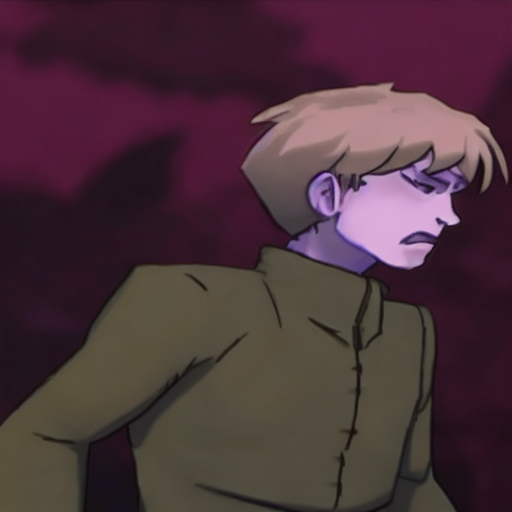

In [5]:
main(prompt = '', \
     content_dir = './testing/angry-context.png', \
     style_dir = './testing/angry-style.png', \
     ddim_steps = 50, \
     strength = 0.7, \
     seed=42, \
     model = model)

In [24]:
import os
import pandas as pd

# Path configurations
content_folder = r"C:\Users\tsriv\Documents\GitHub\InST-implementation\Content"
style_description_csv = r"C:\Users\tsriv\Documents\GitHub\StyleTransfer\style_descriptions.csv"
style_image_path = r"C:\Users\tsriv\Documents\GitHub\StyleTransfer\white.jpg"

# Load the style descriptions from the CSV
style_descriptions = pd.read_csv(style_description_csv)

# Create a dictionary mapping `x` values to the corresponding prompt from style_description.csv
style_prompts = {}
for _, row in style_descriptions.iterrows():
    file_name = row['file_name']
    # Extract x from file_name (e.g., '1.jpg' -> x=1)
    x_value = int(file_name.split('.')[0])
    style_prompts[x_value] = row['style_desc']

# Iterate over all images in the content folder
for file_name in os.listdir(content_folder):
    print(file_name," ")
    if file_name.endswith('.jpg') or file_name.endswith('.png'):
        # Parse x and y from the file name (e.g., '1_1.jpg' -> x=1, y=1)
        x, y = map(int, file_name.split('.')[0].split('_'))
        
        # Get the content image path
        content_image_path = os.path.join(content_folder, file_name)

        # Get the corresponding prompt based on x
        prompt = style_prompts.get(x, "Default prompt if no match found")
        
        # Run the main function with the specific parameters
        print("running main")
        main(
            prompt=prompt,
            content_dir=content_image_path,
            style_dir=style_image_path,
            ddim_steps=50,
            strength=0.7,
            seed=50,
            model=model
        )


Global seed set to 50


1_1.jpg  
running main
loaded input image of size (168, 108) from C:\Users\tsriv\Documents\GitHub\StyleTransfer\white.jpg
loaded input image of size (1361, 1453) from C:\Users\tsriv\Documents\GitHub\InST-implementation\Content\1_1.jpg
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps






































Decoding image: 100%|██████████| 35/35 [06:22<00:00, 10.92s/it]


...

1_4.jpg  
running main
loaded input image of size (168, 108) from C:\Users\tsriv\Documents\GitHub\StyleTransfer\white.jpg
loaded input image of size (608, 723) from C:\Users\tsriv\Documents\GitHub\InST-implementation\Content\1_4.jpg
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps






Sampling:   0%|          | 0/1 [00:42<?, ?it/s]


KeyboardInterrupt: 

In [9]:
import os
import pandas as pd

# Path configurations
content_folder = r"C:\Users\tsriv\Documents\GitHub\InST-implementation\Content"
style_description_csv = r"C:\Users\tsriv\Documents\GitHub\InST-implementation\style_descriptions_1.csv"
style_folder = r"C:\Users\tsriv\Documents\GitHub\InST-implementation\Style"

# Load the style descriptions from the CSV
style_descriptions = pd.read_csv(style_description_csv)

# Create a dictionary mapping `x` values to the corresponding prompt and style image filename from style_description.csv
style_info = {}
for _, row in style_descriptions.iterrows():
    file_name = row['file_name']
    # Extract x from file_name (e.g., '1.jpg' -> x=1)
    x_value = int(file_name.split('.')[0])
    style_info[x_value] = {
        'prompt': row['style_desc'],
        'style_image': os.path.join(style_folder, file_name)  # Path to style image
    }

# Iterate over all images in the content folder
for file_name in os.listdir(content_folder):
    if file_name.endswith(('.jpg', '.jpeg', '.png')):
        print(file_name)
        # Parse x and y from the file name (e.g., '1_1.jpg' -> x=1, y=1)
        x, y = map(int, file_name.split('.')[0].split('_'))
        
        # Get the content image path
        content_image_path = os.path.join(content_folder, file_name)

        # Retrieve the corresponding prompt and style image based on x
        style_data = style_info.get(x)
        if style_data is not None:
            prompt = style_data['prompt']
            style_image_path = style_data['style_image']
            print("running main")
            # Run the main function with the specified parameters
            main(
                prompt=prompt,
                content_dir=content_image_path,
                style_dir=style_image_path,
                ddim_steps=50,
                strength=0.7,
                seed=50,
                model=model
            )
        else:
            print(f"No style information found for x={x}. Skipping file {file_name}.")


Global seed set to 50


1_1.jpg
running main
loaded input image of size (1280, 1480) from C:\Users\tsriv\Documents\GitHub\InST-implementation\Style\1.jpg
loaded input image of size (1361, 1453) from C:\Users\tsriv\Documents\GitHub\InST-implementation\Content\1_1.jpg
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

input_img is None
input_img is None
Running DDIM Sampling with 35 timesteps






































Decoding image: 100%|██████████| 35/35 [05:59<00:00, 10.28s/it]


...

Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

input_img is None
input_img is None
Running DDIM Sampling with 35 timesteps






































Decoding image: 100%|██████████| 35/35 [05:56<00:00, 10.18s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35


Sampling: 100%|██████████| 1/1 [06:14<00:00, 374.33s/it]
